In [3]:
from DataLoader import DataLoader
from tara_preprocessing import get_just_ecog_data,get_electrode_normalized_loc
from tara_preprocessing import remove_duplicates, preprocessing,apply_car_function
from noah_production_funcs import get_1_patient_locations
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm

In [34]:
from torch_geometric.datasets import TUDataset
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool,global_add_pool

In [2]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
ecogs_no_dups,xyz_no_dups = remove_duplicates(ecogs,xyz)
print('Removed duplicate electrodes')
xyz_clean, ecogs_cleaned = preprocessing(ecogs_no_dups,xyz_no_dups,notch_size=.05)
print("Done Preprocessing")

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [45]:
win_size = 800
safety_size = 200
x = 0
k = 10 #number of neareest neighbors for making the graph
max_data_points = 10000000
factor_held_out = 3 #ie number held out is num_nodes / factor_held_out, rounded to nearest int, so bigger factor_held_out means less held out

In [ ]:

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels,num_features_per_node,output_size):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(num_features_per_node, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, output_size)

    def forward(self, x, edge_index,weights,batch=None):
        x = self.conv1(x, edge_index,weights)
        x = self.conv2(x, edge_index,weights)
        x = self.conv3(x, edge_index,weights)
        x = global_add_pool(x, batch).squeeze()
        x = F.relu(self.lin(x))
        
        return x
# hidden_channels: is the size of the input/output of hidden layers
model = GCN(hidden_channels=64,num_features_per_node=win_size,output_size=win_size)

In [62]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_func = torch.nn.CrossEntropyLoss()

In [ ]:
loss_list = []
for pat_index in range(len(ecogs_cleaned)): #for each patient
    pat_locs = get_1_patient_locations(pat_index,ecogs_cleaned,xyz_clean)
    desired_iter_per_node = ecogs_cleaned[pat_index].shape[0]/win_size - safety_size #timeseries length over window size with a little bit of wiggle room for safety
    pat_num_nodes = ecogs_cleaned[pat_index].shape[1]

    list_held = np.random.randint(low=0,high=pat_num_nodes-1,size=int(pat_num_nodes/factor_held_out))
    #print(list_held)
    loader = DataLoader(limit=max_data_points,
                        patient=pat_index,
                        window_size=800,
                        ecogs=ecogs_cleaned,
                        desired_node_iters=desired_iter_per_node,
                        elecs_to_hold=list_held,
                        xyz=pat_locs,
                        k=k)
    for point in loader:
        # point is a dictionary with the following entires:
        # point['edges'] returns the edges matrix
        # point['weights'] returns the edge weights matrix
        # point['features'] returns the matrix of node features
        # point['targets'] returns the held out electrode window to compare to
        ########### PUT YOUR TRAINING HERE ###########
        edges = torch.tensor(point['edges'].T)
        edge_weights = torch.tensor(point['weights'],dtype=torch.float32)
        features = torch.tensor(point['features'],dtype=torch.float32)
        y = torch.tensor(point['target'],dtype=torch.float32)
        optimizer.zero_grad()
        y_pred = model(features,edges,edge_weights)
        loss = loss_func(y_pred,y)
        loss.backward()
        print(loss.detach())
        loss_list.append(loss.detach())
        optimizer.step()  
        


        
        

tensor(4.3877e+12)
tensor(5.9422e+14)
tensor(-5.9195e+15)
tensor(4.3908e+15)
tensor(-1.8665e+15)
tensor(-1.9966e+15)
tensor(7.3648e+15)
tensor(4.5012e+15)
tensor(-3.6144e+15)
tensor(2.6628e+14)
tensor(-1.5319e+15)
tensor(-3.4143e+15)
tensor(-7.5338e+13)
tensor(3.8938e+15)
tensor(-2.6563e+15)
tensor(7.7104e+14)
tensor(1.2665e+15)
tensor(-1.3855e+16)
tensor(8.0028e+15)
tensor(6.0016e+15)
tensor(1.3257e+13)
tensor(-1.3418e+15)
tensor(-3.2139e+16)
tensor(2.4188e+16)
tensor(-8.5224e+15)
tensor(8.1501e+15)
tensor(4.6679e+15)
tensor(-1.0260e+15)
tensor(-6.0657e+15)
tensor(-4.3730e+15)
tensor(-1.6413e+16)
tensor(2.5096e+16)
tensor(3.9953e+15)
tensor(-9.0661e+15)
tensor(-7.6240e+15)
tensor(1.4323e+15)
tensor(-1.3903e+16)
tensor(2.4886e+16)
tensor(1.5423e+16)
tensor(-4.2681e+15)
tensor(-6.9924e+15)
tensor(-8.9142e+15)
tensor(3.4093e+15)
tensor(2.6132e+15)
tensor(1.1314e+16)
tensor(-2.0003e+16)
tensor(-2.7427e+15)
tensor(-5.8816e+15)
tensor(-8.5614e+15)
tensor(6.9650e+15)
tensor(-2.6919e+15)
tens

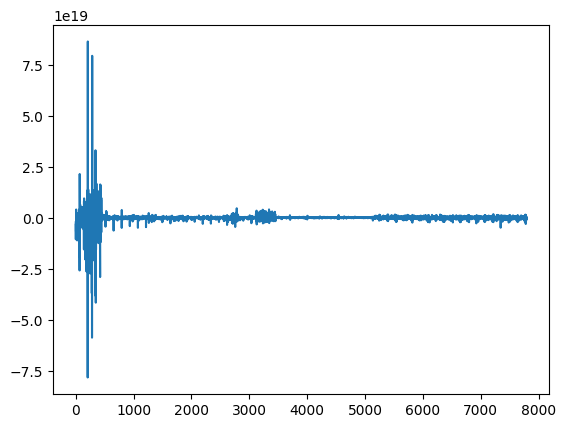

In [65]:
plt.plot(loss_list[15000:])